In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import pickle
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [66]:
# Load models and encoders
cnn = load_model("cnn_model_yelp.h5")

with open("knn_model.pkl", "rb") as f:
    knn = pickle.load(f)

c:\Users\LEGION\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [67]:
label_encoder = joblib.load("label_encoder_updated.pkl")


In [ ]:
try:
    label_encoder = joblib.load("label_encoder_updated.pkl")
except:
    label_encoder = joblib.load("label_encoder.pkl")

In [69]:
# Load and preprocess test images
def preprocess_image(path, size=(224, 224)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img.astype(np.float32) / 255.0
    return img

In [70]:
X_test = []
y_true = []
file_paths = []

In [71]:
test_root = "final_processed_data/test/"
for label in os.listdir(test_root):
    label_path = os.path.join(test_root, label)
    for img_file in os.listdir(label_path):
        img_path = os.path.join(label_path, img_file)
        try:
            img = preprocess_image(img_path)
            X_test.append(img)
            y_true.append(label)
            file_paths.append(img_path)
        except:
            continue

In [72]:
print("Classes in encoder:", label_encoder.classes_[:5])
print("Sample y_true:", y_true[:5])

Classes in encoder: [6. 7.]
Sample y_true: ['drink', 'drink', 'drink', 'drink', 'drink']


In [73]:
str_to_class = {str(i): int(i) for i in label_encoder.classes_}
print("Auto class map (float keys):", str_to_class)

unique_labels = set(y_true)
str_to_class = {label: int(i) for i, label in enumerate(sorted(unique_labels))}
print("Detected classes:", str_to_class)

# Convert y_true strings to encoded integers
y_true_encoded = np.array([str_to_class[label] for label in y_true])

Auto class map (float keys): {'6.0': 6, '7.0': 7}
Detected classes: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


In [74]:
X_test = np.array(X_test)

In [75]:
labels = list(str_to_class.keys())

In [76]:
print(X_test.shape)
print(X_test.dtype)
print(np.min(X_test), np.max(X_test))

(4488, 224, 224, 3)
float32
0.0 1.0


In [77]:
print("X_test shape:", X_test.shape)
print("X_test dtype:", X_test.dtype)
print("Value range:", np.min(X_test), np.max(X_test))
print("Model expects:", cnn.input_shape)

X_test shape: (4488, 224, 224, 3)
X_test dtype: float32
Value range: 0.0 1.0
Model expects: (None, 128, 128, 3)


In [78]:
def preprocess_image(path, size=(128, 128)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img.astype(np.float32) / 255.0
    return img

In [79]:
X_test, y_true, file_paths = [], [], []

test_root = "final_processed_data/test/"
for label in os.listdir(test_root):
    label_path = os.path.join(test_root, label)
    for img_file in os.listdir(label_path):
        img_path = os.path.join(label_path, img_file)
        try:
            img = preprocess_image(img_path, size=(128, 128))
            X_test.append(img)
            y_true.append(label)
            file_paths.append(img_path)
        except:
            continue

X_test = np.array(X_test).astype(np.float32)

In [80]:
# CNN Predictions
cnn_preds = cnn.predict(X_test, verbose=0)
cnn_labels = np.argmax(cnn_preds, axis=1)

In [81]:
def preprocess_image_knn(path, size=(64, 32)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size)
    img = img.astype(np.float32) / 255.0
    return img


In [82]:
X_test = np.array([preprocess_image(p, size=(32, 32)) for p in file_paths])
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [83]:
X_test_knn = np.array([preprocess_image_knn(p) for p in file_paths])
X_test_flat = X_test_knn.reshape(X_test_knn.shape[0], -1)
print("kNN input shape:", X_test_flat.shape)

kNN input shape: (4488, 2048)


In [84]:
knn_labels = knn.predict(X_test_flat)

In [85]:
print("kNN expects features:", knn.n_features_in_)

kNN expects features: 2048


In [86]:
target_features = knn.n_features_in_
side = int(np.sqrt(target_features // 3))  # for RGB
print(f"Resize images to: {side} x {side}")

# Resize accordingly:
X_test = np.array([preprocess_image(p, size=(side, side)) for p in file_paths])
X_test_flat = X_test.reshape(X_test.shape[0], -1)

Resize images to: 26 x 26


In [87]:
X_test_resized = np.array([preprocess_image(p, size=(64, 64)) for p in file_paths])  # or 32x32
X_test_flat = X_test_resized.reshape(X_test_resized.shape[0], -1)


In [88]:
# Majority Voting Ensemble
ensemble_preds = []
for i in range(len(y_true)):
    votes = [cnn_labels[i], knn_labels[i]]
    ensemble_preds.append(max(set(votes), key=votes.count))

In [89]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from tensorflow.keras.utils import to_categorical

def evaluate_model(name, true, pred, prob=None, labels=None, num_classes=None):
    print(f"\n{name} Evaluation")
    
    acc = accuracy_score(true, pred)
    print(f"Accuracy: {acc:.4f}")

    # AUC
    try:
        if prob is not None:
            true_onehot = to_categorical(true, num_classes)
            auc = roc_auc_score(true_onehot, prob, average="macro", multi_class="ovr")
        else:
            pred_onehot = to_categorical(pred, num_classes)
            true_onehot = to_categorical(true, num_classes)
            auc = roc_auc_score(true_onehot, pred_onehot, average="macro", multi_class="ovr")
        print(f"AUC: {auc:.4f}")
    except Exception as e:
        print("AUC: Could not calculate →", e)

    # Confusion Matrix (Inline Only)
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels, cmap='Purples')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [91]:
try:
    labels = list(str_to_class.keys())
except:
    labels = label_encoder.classes_.tolist()

num_classes = len(labels)


CNN Evaluation
Accuracy: 0.8592
AUC: 0.9577


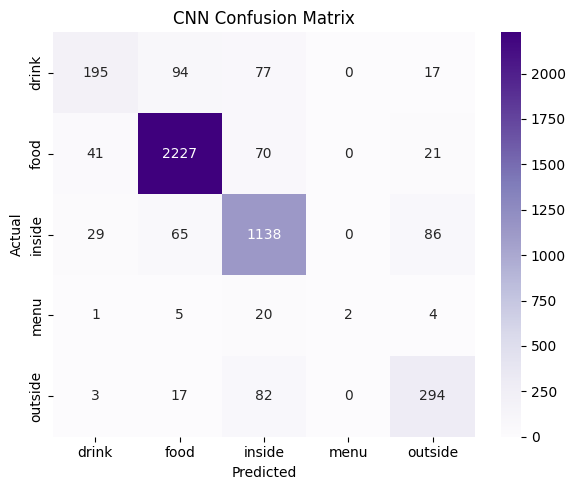


kNN Evaluation
Accuracy: 0.0851
AUC: 0.4997


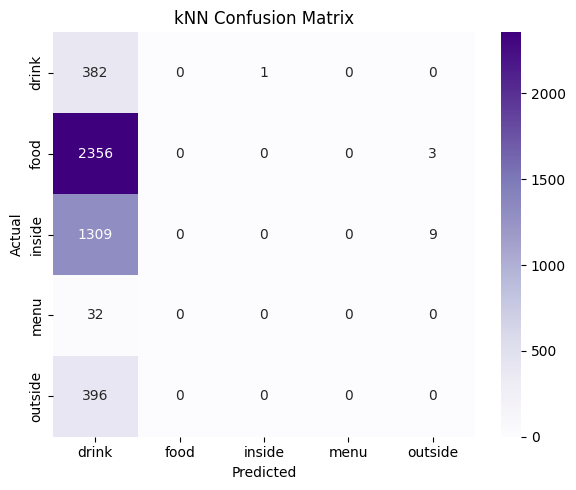


Ensemble Evaluation
Accuracy: 0.0873
AUC: 0.5009


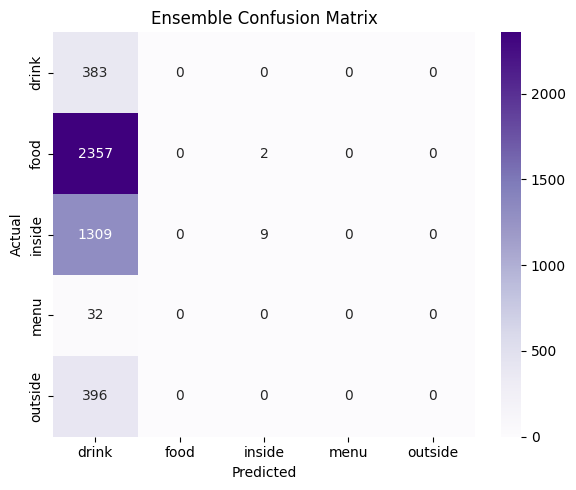

In [92]:
# Final evaluation of all models
evaluate_model("CNN", y_true_encoded, cnn_labels, prob=cnn_preds, labels=labels, num_classes=num_classes)
evaluate_model("kNN", y_true_encoded, knn_labels, labels=labels, num_classes=num_classes)
evaluate_model("Ensemble", y_true_encoded, ensemble_preds, labels=labels, num_classes=num_classes)

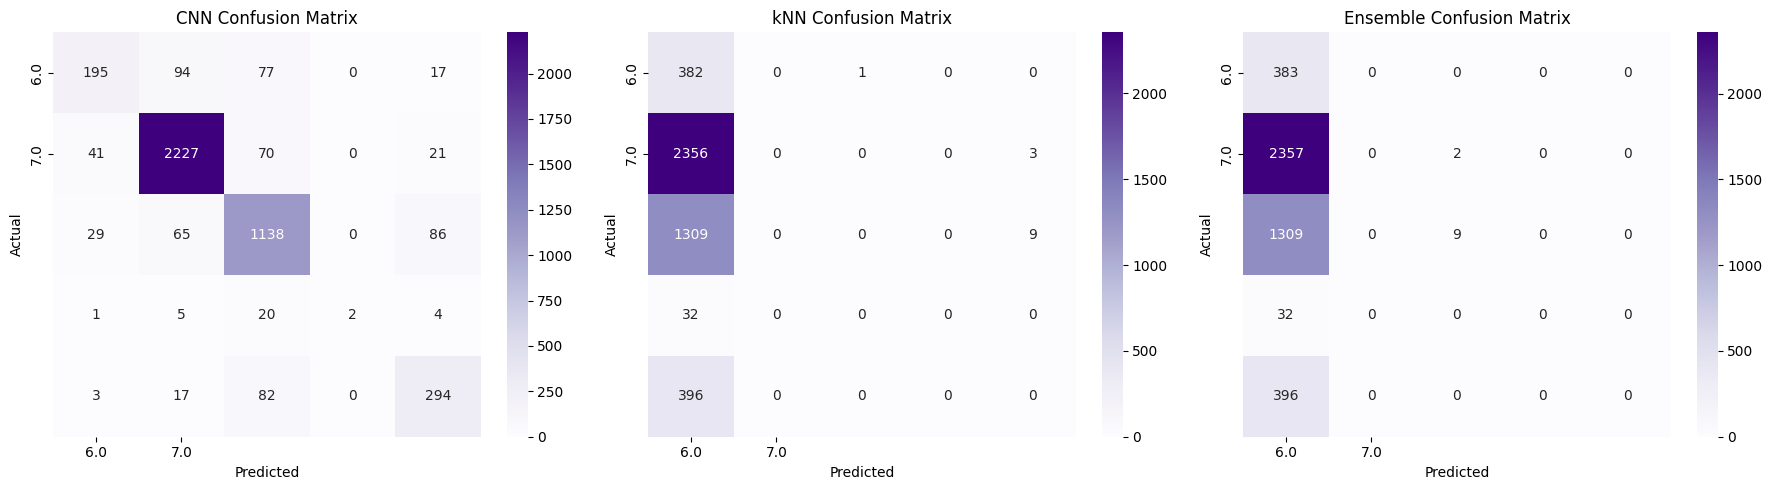

In [ ]:
# Confusion matrix comparison

def plot_confusion_matrix_comparison(y_true, cnn_pred, knn_pred, ensemble_pred, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    models = {
        "CNN": cnn_pred,
        "kNN": knn_pred,
        "Ensemble": ensemble_pred
    }

    for ax, (name, preds) in zip(axes, models.items()):
        cm = confusion_matrix(y_true, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap="Purples", 
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_title(f"{name} Confusion Matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

# Call the function with your values
plot_confusion_matrix_comparison(
    y_true=y_true_encoded,
    cnn_pred=cnn_labels,
    knn_pred=knn_labels,
    ensemble_pred=ensemble_preds,
    labels=labels
)


In [1]:
plot_auc_roc_curves(
    y_true=y_true_encoded,
    cnn_prob=cnn_preds,
    knn_labels=knn_labels,
    ensemble_labels=ensemble_preds,
    num_classes=num_classes
)

NameError: name 'plot_auc_roc_curves' is not defined

In [ ]:
class_to_str = {v: k for k, v in str_to_class.items()}

# Convert predictions
cnn_pred_labels = [class_to_str[i] for i in cnn_labels]
knn_pred_labels = [class_to_str[i] for i in knn_labels]
ensemble_pred_labels = [class_to_str[i] for i in ensemble_preds]

# Save CSV
df = pd.DataFrame({
    "image_path": file_paths,
    "true_label": y_true,
    "cnn_pred": cnn_pred_labels,
    "knn_pred": knn_pred_labels,
    "ensemble_pred": ensemble_pred_labels
})

df.to_csv("ensemble_predictions.csv", index=False)
print("Saved predictions to ensemble_predictions.csv")


Saved predictions to ensemble_predictions.csv
